# 04 — Escalamiento y PCA

**Pregunta (P5):** ¿pueden resumirse las variables numéricas de comportamiento en pocas componentes
principales?

**Variables utilizadas:** `age`, `monthly_watch_time_mins`, `customer_support_tickets` y
`days_since_last_login` (las cuatro numéricas de comportamiento; `user_id` es un identificador y se
excluye). Las filas sin `days_since_last_login` (fecha faltante, ~7,6 %) se excluyen **solo de este
análisis**, porque PCA no admite faltantes y ya se decidió no imputar fechas.

**Escalamiento:** las variables tienen escalas muy distintas (edad en decenas, minutos en miles).
Sin estandarizar, PCA quedaría dominado por la variable de mayor varianza absoluta (los minutos).
Se aplica **StandardScaler** (media 0, desvío 1) para que todas pesen igual.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
df = pd.read_csv("../data/processed/streaming_users_clean.csv", parse_dates=["last_login_date"])

VARIABLES = ["age", "monthly_watch_time_mins", "customer_support_tickets", "days_since_last_login"]
datos = df.dropna(subset=["days_since_last_login"]).copy()
print(f"Filas utilizadas: {len(datos)} de {len(df)} "
      f"({len(df) - len(datos)} excluidas por fecha faltante)")

X = StandardScaler().fit_transform(datos[VARIABLES])
print("Medias tras escalar:", X.mean(axis=0).round(3), "| Desvíos:", X.std(axis=0).round(3))

Filas utilizadas: 7390 de 8000 (610 excluidas por fecha faltante)
Medias tras escalar: [-0.  0. -0.  0.] | Desvíos: [1. 1. 1. 1.]


In [2]:
pca = PCA()
componentes = pca.fit_transform(X)

varianza = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(VARIABLES))],
    "Varianza explicada (%)": (pca.explained_variance_ratio_ * 100).round(1),
    "Acumulada (%)": (pca.explained_variance_ratio_.cumsum() * 100).round(1),
})
varianza

,Componente,Varianza explicada (%),Acumulada (%)
0,PC1,25.5,25.5
1,PC2,25.0,50.6
2,PC3,24.8,75.4
3,PC4,24.6,100.0


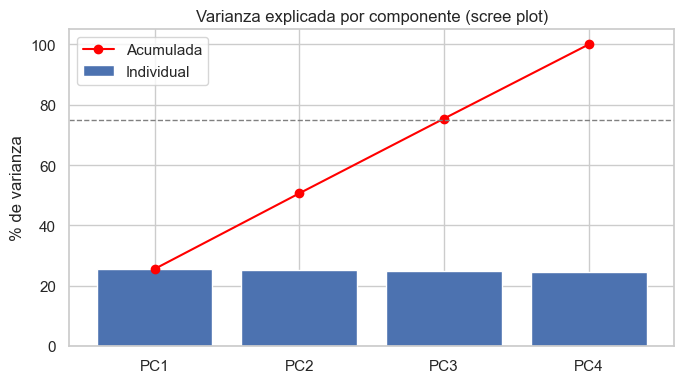

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(varianza["Componente"], varianza["Varianza explicada (%)"], label="Individual")
ax.plot(varianza["Componente"], varianza["Acumulada (%)"], color="red", marker="o", label="Acumulada")
ax.axhline(75, color="gray", linestyle="--", linewidth=1)
ax.set_title("Varianza explicada por componente (scree plot)")
ax.set_ylabel("% de varianza")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación de la varianza:** las cuatro componentes explican porcentajes casi idénticos
(~25 % cada una): se necesitan **3 de 4 componentes para alcanzar el 75 %** de la varianza.
Esto es consecuencia directa de lo visto en el EDA: las variables numéricas están incorrelacionadas
(|r| < 0,02), por lo que **no existe redundancia que PCA pueda comprimir**. Es un resultado válido y
documentado: PCA confirma que cada variable aporta información propia, no reducible a la de las demás.

In [4]:
cargas = pd.DataFrame(pca.components_.T,
                      index=VARIABLES,
                      columns=[f"PC{i+1}" for i in range(len(VARIABLES))]).round(3)
cargas

,PC1,PC2,PC3,PC4
age,0.623,0.180,-0.324,0.689
monthly_watch_time_mins,0.486,-0.185,0.854,0.012
customer_support_tickets,0.176,0.914,0.103,-0.350
days_since_last_login,-0.588,0.312,0.393,0.635


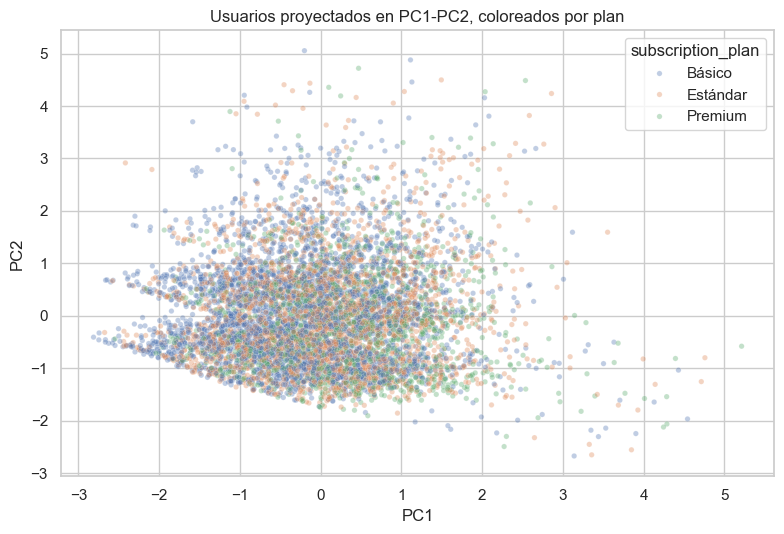

In [5]:
datos["PC1"] = componentes[:, 0]
datos["PC2"] = componentes[:, 1]
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(data=datos, x="PC1", y="PC2", hue="subscription_plan",
                hue_order=["Básico", "Estándar", "Premium"], alpha=0.35, s=15, ax=ax)
ax.set_title("Usuarios proyectados en PC1-PC2, coloreados por plan")
plt.tight_layout()
plt.show()

**Interpretación de las componentes:**

- **PC1** combina edad y consumo con signo positivo y recencia con signo negativo: contrasta usuarios
  "activos" (más consumo, login reciente) con usuarios "alejados". **PC2** está dominada por los tickets
  de soporte (carga ≈ 0,91), es decir, la dimensión de "fricción con el servicio".
- En la proyección PC1-PC2 los planes aparecen **superpuestos y sin clusters**: los grupos de consumo
  que el EDA detectó por plan no forman grupos separados una vez que el consumo se mezcla con las otras
  tres variables incorrelacionadas.

**Conclusión (P5):** no es posible resumir estas cuatro variables en pocas componentes: la estructura
del dataset es de variables independientes. La segmentación útil de usuarios pasa por las variables
categóricas (plan) y no por combinaciones lineales de las numéricas.